In [1]:
# importing libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

In [2]:
# 1. importing database/ data

conn = sqlite3.connect(r"C:\Users\ragha\OneDrive\Desktop\Projects\Churn_Analysis\customer_churn_database.db")

sql_query = '''
        SELECT name
        FROM sqlite_master
        WHERE type = 'table'
'''

tables = pd.read_sql(sql_query, conn)

# creating dataframe for each table
for table_name in tables['name']:
    df = pd.read_sql(f'SELECT * FROM {table_name}', conn)
    globals()[f'df_{table_name}'] = df
    print(f'Created dataframe: df_{table_name}')

conn.close()

Created dataframe: df_db_customer
Created dataframe: df_db_subscription
Created dataframe: df_db_support


In [3]:
# printing tables name & columns name

conn = sqlite3.connect(r"C:\Users\ragha\OneDrive\Desktop\Projects\Churn_Analysis\customer_churn_database.db")

for table_name in tables['name']:
    print(f'Table Name: {table_name}')

    # Getting column info
    columns_query = f'PRAGMA table_info({table_name});'
    columns = pd.read_sql(columns_query, conn)
    print('Columns:')
    print(columns['name'].tolist())
    print()

# Closing connection
conn.close()

Table Name: db_customer
Columns:
['customerid', 'name', 'country', 'state', 'gender', 'dob', 'interests', 'pincode']

Table Name: db_subscription
Columns:
['customerid', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score']

Table Name: db_support
Columns:
['customerid', 'complaint_date', 'escalations', 'csat_score', 'col_1', 'comment']



In [4]:
# 2. Data CLeaning

In [5]:
df_db_customer.head()

,customerid,name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,None,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,None,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None


In [6]:
df_db_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  21 non-null     object
 1   name        21 non-null     object
 2   country     18 non-null     object
 3   state       21 non-null     object
 4   gender      21 non-null     object
 5   dob         21 non-null     object
 6   interests   4 non-null      object
 7   pincode     0 non-null      object
dtypes: object(8)
memory usage: 1.4+ KB


In [7]:
# a. renaming column - name
# b. dropping columns - interests and pincode
# c. changing data type - dob
# d. data standardization - gender
# e. fixing missing values - country

In [8]:
# a. renaming column - name

df_db_customer.rename(columns = {'name' : 'customer_name'}, inplace=True)

In [9]:
# b. dropping columns - interests and pincode

df_db_customer.drop(columns = ['interests', 'pincode'], inplace = True)

In [10]:
# c. changing data type - dob

df_db_customer['dob'] = pd.to_datetime(df_db_customer['dob'])

In [11]:
# d. data standardization - gender

df_db_customer['gender']=df_db_customer['gender'].replace({'Men' : 'Male', 'Women' : 'Female'})

In [12]:
df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob
5,0013-MHZWF,durga,None,Delhi,Female,1988-12-10
8,0015-UOCOJ,maya,None,Kathmandu,Female,1985-07-07
12,0018-NYROU,chitra,None,Telangana,Female,2004-12-01


In [13]:
# e. fixing missing values - country

state_country_mapping = df_db_customer.dropna(subset = ['country']).set_index('state')['country'].to_dict()

df_db_customer['country']=df_db_customer['country'].fillna(df_db_customer['state'].map(state_country_mapping))

In [14]:
df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob


In [15]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,None,None,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,None,None,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,None,None,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [16]:
df_db_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               21 non-null     object 
 1   subscription_start_date  21 non-null     object 
 2   subscription_type        21 non-null     object 
 3   renewal_date             21 non-null     object 
 4   plan_type                21 non-null     object 
 5   contract_type            21 non-null     object 
 6   cancellation_date        6 non-null      object 
 7   cancellation_reason      6 non-null      object 
 8   monthly_charges          21 non-null     float64
 9   cltv                     21 non-null     int64  
 10  churn_score              21 non-null     int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 1.9+ KB


In [17]:
date_col= ['subscription_start_date', 'renewal_date', 'cancellation_date']

df_db_subscription[date_col]=df_db_subscription[date_col].apply(pd.to_datetime)
df_db_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               21 non-null     object        
 1   subscription_start_date  21 non-null     datetime64[ns]
 2   subscription_type        21 non-null     object        
 3   renewal_date             21 non-null     datetime64[ns]
 4   plan_type                21 non-null     object        
 5   contract_type            21 non-null     object        
 6   cancellation_date        6 non-null      datetime64[ns]
 7   cancellation_reason      6 non-null      object        
 8   monthly_charges          21 non-null     float64       
 9   cltv                     21 non-null     int64         
 10  churn_score              21 non-null     int64         
dtypes: datetime64[ns](3), float64(1), int64(2), object(5)
memory usage: 1.9+ KB


In [18]:
df_db_support.head()

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,None
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,None


In [19]:
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      9 non-null      object
 1   complaint_date  9 non-null      object
 2   escalations     9 non-null      object
 3   csat_score      9 non-null      int64 
 4   col_1           0 non-null      object
 5   comment         4 non-null      object
dtypes: int64(1), object(5)
memory usage: 564.0+ bytes


In [20]:
df_db_support.drop(columns = ['col_1', 'comment'], inplace = True)

In [21]:
df_db_support['complaint_date'] = pd.to_datetime(df_db_support['complaint_date'])
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customerid      9 non-null      object        
 1   complaint_date  9 non-null      datetime64[ns]
 2   escalations     9 non-null      object        
 3   csat_score      9 non-null      int64         
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 420.0+ bytes


In [22]:
# Feature Engineering and Data Analysis

In [23]:
# Creating a new column from existing column- churn flag
df_db_subscription['churn_flag'] = np.where(df_db_subscription['cancellation_date'].notna(),1,0)

In [24]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,12,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,34,0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,8,0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1


In [25]:
# fixing support table duplicates and then merge

In [26]:
df = (df_db_subscription
    .merge(df_db_customer, on = 'customerid', how = 'left')
    .merge(df_db_support, on = 'customerid', how = 'left'))

In [27]:
df.shape

(23, 20)

In [28]:
df_db_subscription.shape

(21, 12)

In [29]:
df_db_subscription['customerid'].nunique()

21

In [30]:
df_db_customer['customerid'].nunique()

21

In [31]:
df_db_support['customerid'].nunique()

7

In [32]:
df_db_support['customerid'].size

9

In [33]:
df_db_support

,customerid,complaint_date,escalations,csat_score
0,0003-MKNFE,2024-08-28,N,60
1,0003-MKNFE,2024-08-28,Y,10
2,0013-EXCHZ,2024-01-20,Y,20
3,0013-MHZWF,2025-03-18,N,90
4,0013-SMEOE,2024-11-01,N,30
5,0017-IUDMW,2024-04-10,Y,25
6,0019-EFAEP,2024-09-27,Y,30
7,0022-TCJCI,2024-09-13,Y,10
8,0022-TCJCI,2024-09-14,N,90


In [34]:
df_db_support['complaint_count']=df_db_support.groupby('customerid')['customerid'].transform('count')

In [35]:
df_db_support

,customerid,complaint_date,escalations,csat_score,complaint_count
0,0003-MKNFE,2024-08-28,N,60,2
1,0003-MKNFE,2024-08-28,Y,10,2
2,0013-EXCHZ,2024-01-20,Y,20,1
3,0013-MHZWF,2025-03-18,N,90,1
4,0013-SMEOE,2024-11-01,N,30,1
5,0017-IUDMW,2024-04-10,Y,25,1
6,0019-EFAEP,2024-09-27,Y,30,1
7,0022-TCJCI,2024-09-13,Y,10,2
8,0022-TCJCI,2024-09-14,N,90,2


In [36]:
df_db_support = df_db_support.sort_values('complaint_date').drop_duplicates('customerid', keep = 'last')

In [37]:
df_db_support['customerid'].size

7

In [38]:
# merging df
df = (df_db_subscription
    .merge(df_db_customer, on = 'customerid', how = 'left')
    .merge(df_db_support, on = 'customerid', how = 'left'))

In [39]:
df.to_csv('exported_churn_data.csv',index = False)

In [40]:
df.shape

(21, 21)

In [41]:
# Data Analysis

In [42]:
# 1. Churn Rate

In [43]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count'],
      dtype='object')

In [44]:
churn_rate = df['churn_flag'].mean()*100
print('Churn Rate =',round(churn_rate,2), '%')

Churn Rate = 28.57 %


In [45]:
# 2. Retention Rate
retention_rate = 100 - churn_rate
print('Retention Rate =', round(retention_rate,2), '%')

Retention Rate = 71.43 %


In [46]:
# 3. Churn by Plan Type
churn_by_plan = (df.groupby('plan_type')['churn_flag'].mean().mul(100).round(2).reset_index(name='churn_rate_pct'))
print(churn_by_plan)

  plan_type  churn_rate_pct
0     Basic           60.00
1   Premium           14.29
2  Standard           22.22


In [47]:
# 4 a. Churn by state + sum(revenue) & count of users

churn_by_state = df.groupby('state').agg(
    churn_rate_pct_by_state=('churn_flag', 'mean'),
    total_revenue=('monthly_charges', 'sum'),
    user_count=('customerid', 'count')
).reset_index()

churn_by_state['churn_rate_pct_by_state'] = (
    churn_by_state['churn_rate_pct_by_state'] * 100
).round(2)

print(churn_by_state)

           state  churn_rate_pct_by_state  total_revenue  user_count
0          Delhi                    25.00          52.96           4
1      Karnataka                   100.00          20.98           2
2      Kathmandu                     0.00          20.98           2
3    Maharashtra                     0.00          50.97           3
4      Meghalaya                    66.67          42.97           3
5       Nagaland                     0.00          22.99           1
6      Rajasthan                     0.00          36.98           2
7      Telangana                    50.00          30.98           2
8  Uttar Pradesh                     0.00         115.98           2


In [48]:
# 4 b. Churn by subscription type + sum(revenue) & count of users

churn_by_subscription_type = df.groupby('plan_type').agg(
    churn_rate_pct_by_subscription_type=('churn_flag', 'mean'),
    total_revenue=('monthly_charges', 'sum'),
    user_count=('customerid', 'count')
).reset_index()

churn_by_subscription_type['churn_rate_pct_by_subscription_type'] = (
    churn_by_subscription_type['churn_rate_pct_by_subscription_type'] * 100
).round(2)

print(churn_by_subscription_type)

  plan_type  churn_rate_pct_by_subscription_type  total_revenue  user_count
0     Basic                                60.00          52.95           5
1   Premium                                14.29         218.93           7
2  Standard                                22.22         123.91           9


In [49]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count'],
      dtype='object')

In [50]:
# 5a. ARPU - Avg Revenue per user
arpu = df['monthly_charges'].mean()
print('ARPU =', round(arpu,2))

ARPU = 18.85


In [51]:
# 5b. Customer Age

today = pd.Timestamp.today()

df['customer_age'] = np.where(df['dob'].notna(),
                    (today.year - df['dob'].dt.year),0)

In [52]:
# 6. Avg customer tenure 
# count of days user has used our service : cancellation date else current date

today = pd.Timestamp.today()

df['tenure_days'] = np.where(df['cancellation_date'].notna(),            
                    (df['cancellation_date'] - df['subscription_start_date']).dt.days,
                    (today - df['subscription_start_date']).dt.days
)
avg_tenure = df['tenure_days'].mean()
print('Avg Tenure (Days) =', round(avg_tenure))

Avg Tenure (Days) = 1532


In [53]:
# 7. Revenue at risk/ Revenue lost from churned users

revenue_at_risk = df.loc[df['churn_flag'] == 1, 'monthly_charges'].sum()
print("Revenue at risk (Rs 'K') =", revenue_at_risk)

Revenue at risk (Rs 'K') = 73.94


In [54]:
# 8. Escalation Rate

escalation_rate = (df['escalations'] == 'Y').mean()*100
print('Escalation Rate =', round(escalation_rate,2), '%')

Escalation Rate = 19.05 %


In [55]:
# 9. Avg Complaint rate per user
avg_complaints = df['complaint_count'].sum()/ df['customerid'].nunique()
print('Avg complaints per user = ', round(avg_complaints,2))

Avg complaints per user =  0.43


In [56]:
# 10.Correlation Escalation vs Churn

df['escalations'] = np.where(df['escalations'] == 'Y', 1, 0) # encoding string to int type
corr_df = df[['escalations', 'churn_flag']].dropna()

correlation = corr_df['escalations'].corr(corr_df['churn_flag'])
print('Correlation between escalation and churn_flag is', round(correlation,2))

Correlation between escalation and churn_flag is 0.77


In [57]:
# Creating a column using existing column - churn risk

conditions = [
        (df['churn_score'] < 50),
        (df['churn_score'] >= 50) & (df['churn_score'] < 70),
        (df['churn_score'] >= 70)    
]

choices = ['low','med','high']

df['churn_risk'] = np.select(conditions, choices, default = 'unknown')

In [58]:
# 4. Visulization using Matplotlib

In [59]:
df_visual = df.copy()

In [60]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'customer_age', 'tenure_days', 'churn_risk'],
      dtype='object')

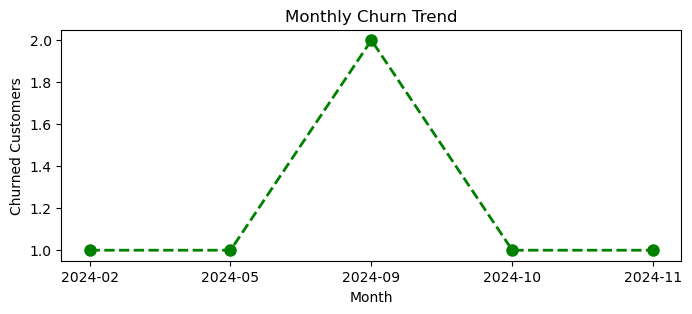

In [61]:
# 4.1 Monthly Churn Trend

df_visual['cancellation_month'] = df_visual['cancellation_date'].dt.to_period('M')

churn_trend = df_visual[df_visual['churn_flag'] == 1].groupby('cancellation_month').size()

plt.figure(figsize=(8,3))
plt.plot(churn_trend.index.astype(str), churn_trend.values, color = 'g', marker = 'o',  linestyle = 'dashed', linewidth = 2, markersize = 8)

plt.title('Monthly Churn Trend')
plt.xlabel('Month')
plt.ylabel('Churned Customers')
plt.show()

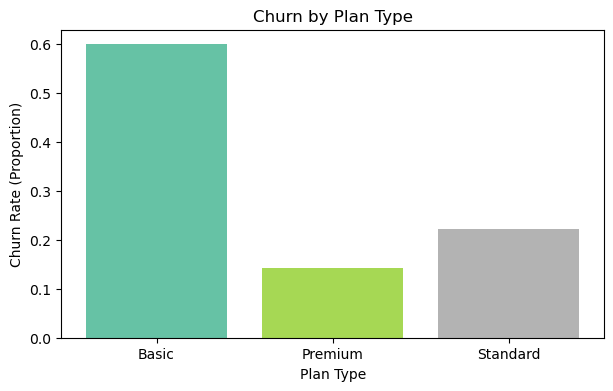

In [62]:
# 4.2 Churn by Plan Type

churn_plan = df_visual.groupby('plan_type')['churn_flag'].mean()

colors = plt.cm.Set2(np.linspace(0,1,len(churn_plan)))

plt.figure(figsize=(7,4))
plt.bar(churn_plan.index, churn_plan.values, color = colors)
plt.title('Churn by Plan Type')
plt.xlabel('Plan Type')
plt.ylabel('Churn Rate (Proportion)')
plt.show()

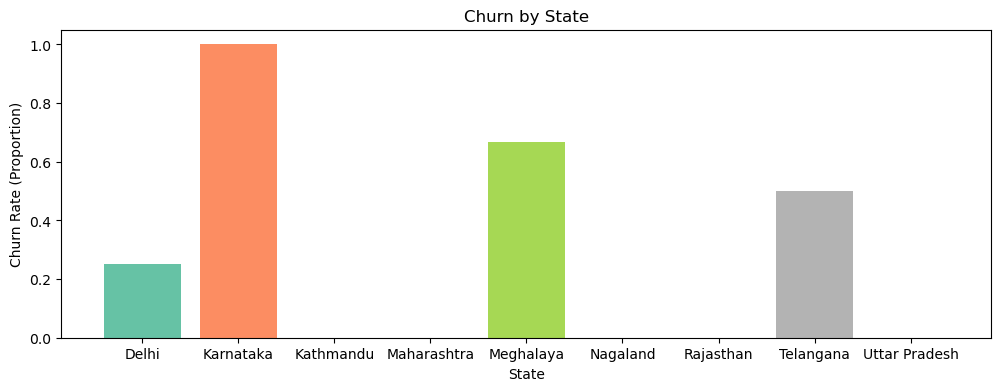

In [63]:
# 4.3 Churn by State Type

churn_state = df_visual.groupby('state')['churn_flag'].mean()

colors = plt.cm.Set2(np.linspace(0,1,len(churn_state)))

plt.figure(figsize=(12,4))
plt.bar(churn_state.index, churn_state.values, color = colors)
plt.title('Churn by State')
plt.xlabel('State')
plt.ylabel('Churn Rate (Proportion)')
plt.show()

In [64]:
# Visualization using Seaborn

In [65]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'customer_age', 'tenure_days', 'churn_risk', 'cancellation_month'],
      dtype='object')

In [66]:
# Encoding - converting str to numeric so that we can find correlation between features

In [67]:
import warnings
warnings.filterwarnings('ignore')

In [68]:
# incorrect method of encoding - as numbers are not based on priority

df_encoded = df_visual[['plan_type', 'contract_type', 'churn_score', 'churn_flag', 'escalations', 'churn_risk']]

categorical_cols = ['plan_type','contract_type','churn_risk']

for col in categorical_cols:
    df_encoded[col] = df_encoded[col].astype('category').cat.codes

In [69]:
df_encoded.head()

,plan_type,contract_type,churn_score,churn_flag,escalations,churn_risk
0,2,0,12,0,0,1
1,1,0,91,1,1,0
2,0,1,34,0,0,1
3,1,0,8,0,0,1
4,2,1,88,1,1,0


<Axes: >

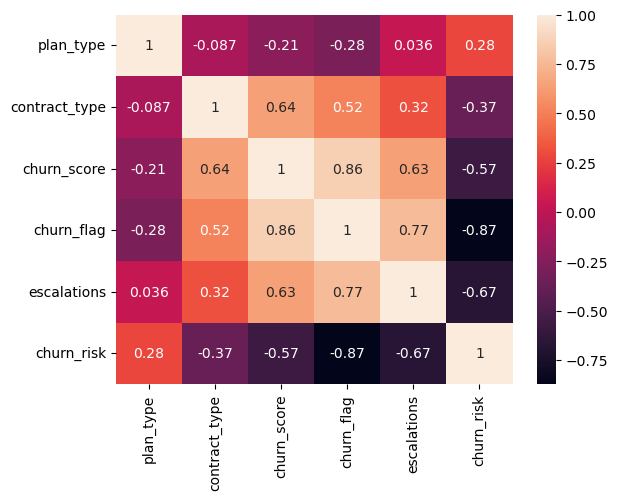

In [70]:
# Heatmap (Correlation Matrix)

sns.heatmap(df_encoded.corr(), annot = True)

In [71]:
df_visual['churn_risk'].unique()

array(['low', 'high', 'med'], dtype=object)

In [72]:
# Correct method of encoding - based on priority

df_encoded = df_visual[['plan_type', 'contract_type', 'churn_score', 'churn_flag', 'escalations', 'churn_risk']]

order_mappings = {
    'plan_type' : ['Basic', 'Standard', 'Premium'],
    'contract_type' : ['Monthly', 'Annual'],
    'churn_risk' : ['low', 'med', 'high']
}

for col, order in order_mappings.items():
    df_encoded[col] = pd.Categorical(df_encoded[col], categories = order, ordered = True).codes

In [73]:
df_encoded.head()

,plan_type,contract_type,churn_score,churn_flag,escalations,churn_risk
0,1,1,12,0,0,0
1,2,1,91,1,1,2
2,0,0,34,0,0,0
3,2,1,8,0,0,0
4,1,0,88,1,1,2


<Axes: >

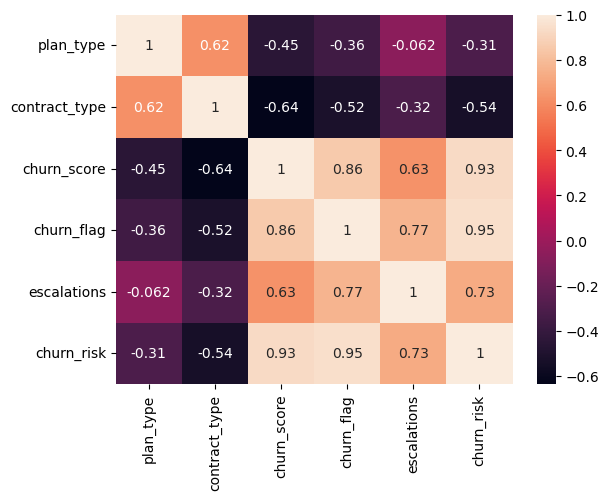

In [74]:
# Heatmap (Correlation Matrix)

sns.heatmap(df_encoded.corr(),  annot = True)

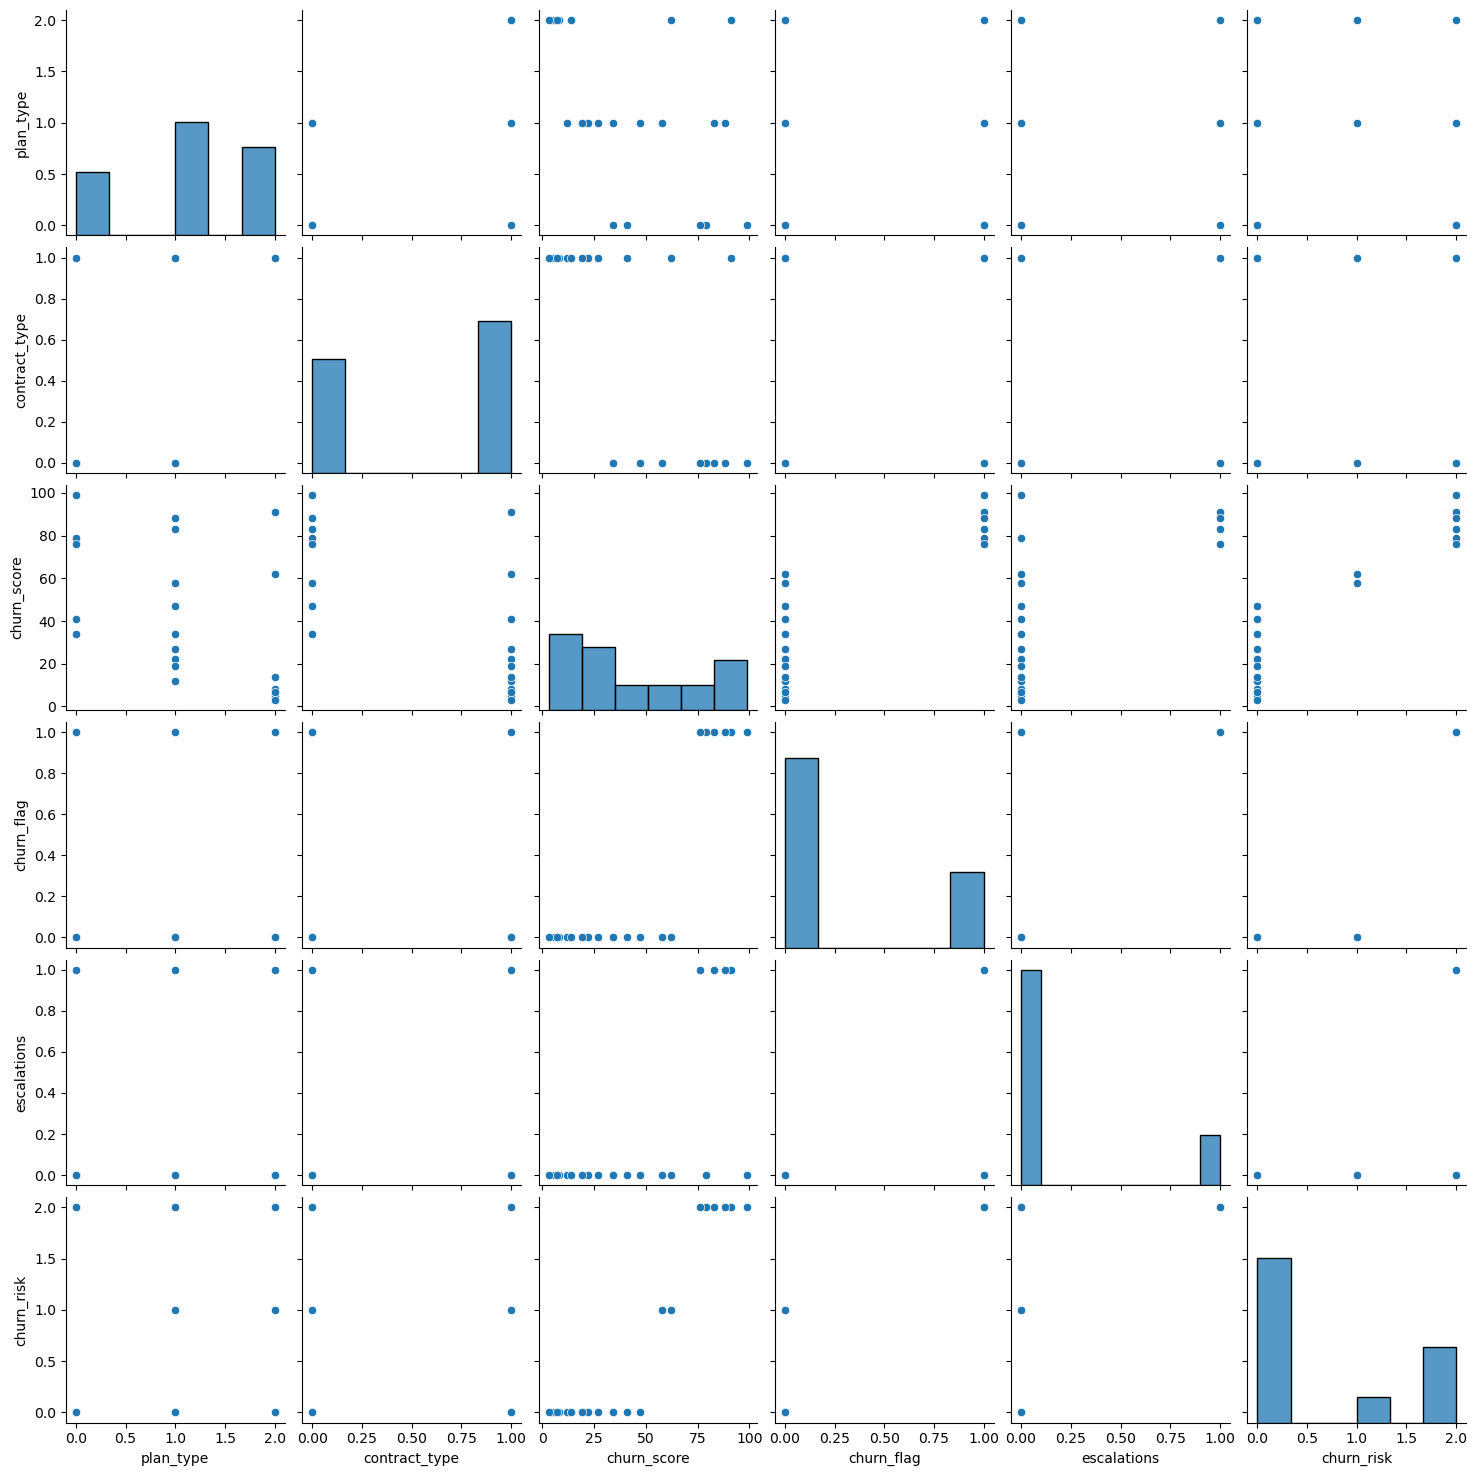

In [75]:
#Pairplot - relationship in a dataset
sns.pairplot(df_encoded)

In [76]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'customer_age', 'tenure_days', 'churn_risk', 'cancellation_month'],
      dtype='object')

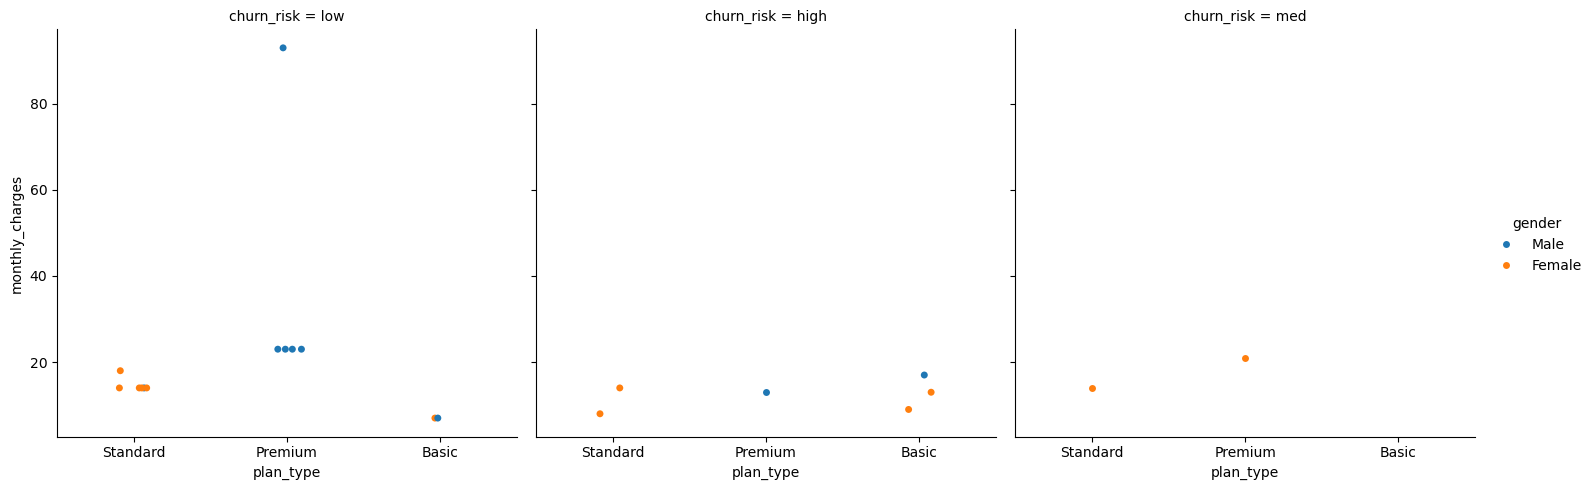

In [77]:
# catplt/ Facegrid chart - multi dim comparison

sns.catplot(data=df_visual, x = 'plan_type', y = 'monthly_charges',  hue = 'gender',col = 'churn_risk')

In [78]:
# Pivot Table

pd.pivot_table(
    df_visual,
    values = 'churn_flag',
    index = 'plan_type',
    aggfunc = 'mean'
    
).reset_index()

,plan_type,churn_flag
0,Basic,0.600000
1,Premium,0.142857
2,Standard,0.222222


In [79]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'customer_age', 'tenure_days', 'churn_risk', 'cancellation_month'],
      dtype='object')

In [80]:
# Pivot Table

pd.pivot_table(
    df_visual,
    index = 'plan_type',
    values = ['monthly_charges', 'customerid', 'churn_flag'],
    aggfunc = {'monthly_charges' : 'sum',
               'customerid' : 'nunique',
               'churn_flag' : 'mean'}
    
)

,churn_flag,customerid,monthly_charges
plan_type,,,
Basic,0.600000,5,52.95
Premium,0.142857,7,218.93
Standard,0.222222,9,123.91


In [81]:
# Working with SQL in Python (Pandas)

In [83]:
# Creating db in SQL

conn = sqlite3.connect('test_database.sqlite')

# Tables details
conn.execute('CREATE TABLE userss(first_name TEXT, country TEXT, budget INTEGER)')

# Commit and save
conn.commit()

In [84]:
# Inserting data

cursor = conn.cursor()


# writing sql query to insert records in sql table
cursor.execute(
    """
        INSERT INTO userss VALUES
        ('Madhav', 'india', 5000),
        ('Rishabh', 'Germany', 2500),
        ('Vishakha', 'India', 3500)
    """
)

# Commit and Save
conn.commit()

In [85]:
# Checking inserted in table

conn = sqlite3.connect('test_database.sqlite')
query = """SELECT * FROM userss"""

df_results = pd.read_sql(query, conn)

df_results.head()

,first_name,country,budget
0,Madhav,india,5000
1,Rishabh,Germany,2500
2,Vishakha,India,3500
